# NIVEL 1

1. 
    * Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importe correctamente, con los nombres de columnas correspondientes, sin manipular el archivo original.
    * Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.
    * Muestra las primeras 10 filas.
* Adicionalmente, haz un print para comprobar que el DNI solo tiene valores únicos

In [19]:
import pandas as pd
import numpy as np
# pip install jinja2
from datetime import date
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [20]:
# Se importa dataframe
df = pd.read_excel("sprint10.xlsx", header=3, index_col=0)

#Se ordena por Pais y Ciudad
df.sort_values(["País d'origen", "Ciutat"], inplace=True)

#Se muestra 10 primeras filas
df.head(10)


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [21]:
print("¿DNI tiene solo valores únicos?:", df['DNI'].is_unique)

¿DNI tiene solo valores únicos?: True


2.
    * Crea una columna que sea el nombre completo.
    * Crea una columna si la persona ha nacido en España o no.
    * Coloca el DNI como índice del DataFrame (nombres de filas).
    * Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.
    * Sustituye H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (nan/null/na).
* Muestra todos los cambios que has realizado en una sola tabla.

In [22]:
# Crea una sola columna con Nom y Cognoms
df["Nom_complet"] = df["Nom"] + [' '] + df["Cognoms"]

#Para colocar la columna al inicio de la tabla
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index("Nom_complet")))
df = df[cols]

# Crea columna de Nacimiento en España (Si/No)
df["Naixement_Espanya"] = np.where(df["País d'origen"] == "Espanya", "Si", "No")

# Coloca como Indice la columna "DNI"
df.set_index("DNI", inplace=True)

# Sustituye nombre de columnas
df.rename (columns= {"Dia de Naixement":"Dia", "Mes de Naixement": "Mes", "Any de Naixement":"Año"}, inplace = True)

#Sustituye Valores de la columna "Genere"
df["Gènere"] = df["Gènere"].replace(["H","D", "A","NC"], ["Hombre", "Mujer", "Otros", np.nan] )
# df.isnull().any() # Veo que columnas tiene valores nan
# df.isnull().sum() # Veo la cantidad de valores nan en cada columna.

# Mostrar tabla con cambios realizados
df_mostrar = df.drop(columns=["Nom", "Cognoms"])
df_mostrar.head(15)


,Nom_complet,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Naixement_Espanya
DNI,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951 €,NaN,1.0,Grup A,No
37399141L,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1.769 €,1.0,NaN,Grup B,No
37368317L,Lea Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2.013 €,NaN,1.0,Grup B,No
21390098Z,Mia Fischer,Alemanya,Berlín,11,8,1950,Mujer,1.557 €,1.0,NaN,Grup B,No
44060014R,Jonas Schneider,Alemanya,Berlín,22,11,1985,Hombre,2.754 €,1.0,NaN,Grup D,No
14773153R,Lea Fischer,Alemanya,Berlín,9,9,1986,Mujer,1.370 €,1.0,NaN,Grup A,No
23266650S,Lea Müller,Alemanya,Hamburg,14,4,2003,Mujer,1.314 €,NaN,1.0,Grup A,No
83274277X,Anna Müller,Alemanya,Hamburg,1,1,1987,Mujer,2.464 €,NaN,1.0,Grup C,No
60161784X,Laura Schmidt Müller,Alemanya,Hamburg,15,6,1987,NaN,2.035 €,1.0,NaN,Grup C,No


3. 
   * Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".


In [23]:
def juntar_columnas(fila):
    if fila ["Fills"] == 1.0:
        val = "Si"
    elif fila ["No Fills"] == 1.0:
        val = "No"
    else:
        val = None
    return val
#df["Té_Fills"] = df.apply(juntar_columnas, axis=1) # previo para verificar que se generó bien la columna.
df_mostrar["Fills"] = df_mostrar.apply(juntar_columnas, axis=1)
df_mostrar.drop("No Fills", axis=1, inplace=True)
df_mostrar.head(15)

,Nom_complet,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,Grup Professional,Naixement_Espanya
DNI,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951 €,No,Grup A,No
37399141L,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1.769 €,Si,Grup B,No
37368317L,Lea Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2.013 €,No,Grup B,No
21390098Z,Mia Fischer,Alemanya,Berlín,11,8,1950,Mujer,1.557 €,Si,Grup B,No
44060014R,Jonas Schneider,Alemanya,Berlín,22,11,1985,Hombre,2.754 €,Si,Grup D,No
14773153R,Lea Fischer,Alemanya,Berlín,9,9,1986,Mujer,1.370 €,Si,Grup A,No
23266650S,Lea Müller,Alemanya,Hamburg,14,4,2003,Mujer,1.314 €,No,Grup A,No
83274277X,Anna Müller,Alemanya,Hamburg,1,1,1987,Mujer,2.464 €,No,Grup C,No
60161784X,Laura Schmidt Müller,Alemanya,Hamburg,15,6,1987,NaN,2.035 €,Si,Grup C,No


4.
    * Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
    * Ordena la taula en funció del sou mig.


In [24]:
# verifico el tipo de dato de la columna Salari mensual.
df_mostrar["Salari mensual"].dtype

dtype('O')

In [25]:
def neteja_salari(num):
    num = str(num).replace("€", "").replace(".", "").strip()
    return float(num) if num else None
df_mostrar["Salari mensual"] = df_mostrar["Salari mensual"].apply(neteja_salari)

In [36]:
tabla_resum = df_mostrar.groupby("Gènere")["Salari mensual"].agg(sou_mig = "mean", sou_medià = "median", sou_mínim = "min", sou_máxim = "max"). sort_values("sou_mig")
tabla_resum = tabla_resum.round(2)
tabla_resum

,sou_mig,sou_medià,sou_mínim,sou_máxim
Gènere,,,,
Mujer,1469.44,1361.5,665.0,3021.0
Otros,1626.59,1545.0,703.0,3175.0
Hombre,1643.25,1531.0,737.0,3356.0


5. 
    * Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
    * Afegeix-hi les mitjanes als marges de la taula.
* (EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats


In [27]:
tabla = pd.pivot_table(df_mostrar, values="Salari mensual", index="Gènere", columns="País d'origen", aggfunc="mean", margins= True, margins_name="Mitjana")
tabla = tabla.round(2)
#tabla.style.background_gradient(cmap="YlOrRd")
#tabla.style.background_gradient(cmap="Greens")
# tabla.style.highlight_max(color="#158127") # por columna
# tabla.style.highlight_max(axis=1, color="#00aeff") # por fila
tabla.style \
    .format("{:.2f}") \
    .highlight_max(axis=0, color="#158127") \
    .highlight_max(axis=1, color="#220cb1") # VErde para columnas y azul para filas.
    

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana
Gènere,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Mitjana,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


6.
    * Crea una columna nova que sigui la data de naixement en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
    * Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.


In [28]:
df_mostrar["data_naixement"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes"], day=df["Dia"]))

def calcular_edat(data_naixement):
    avui = date.today()
    anys = avui.year - data_naixement.year
    # restar 1 si aún no ha cumplido años este año
    if (avui.month, avui.day) < (data_naixement.month, data_naixement.day):
        anys -= 1
    return anys

df_mostrar["Edat"] = df_mostrar["data_naixement"].apply(calcular_edat)

df_mostrar.head(15)

,Nom_complet,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,Grup Professional,Naixement_Espanya,data_naixement,Edat
DNI,,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951.0,No,Grup A,No,1976-10-22,49
37399141L,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1769.0,Si,Grup B,No,1958-02-02,67
37368317L,Lea Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2013.0,No,Grup B,No,2005-10-23,20
21390098Z,Mia Fischer,Alemanya,Berlín,11,8,1950,Mujer,1557.0,Si,Grup B,No,1950-08-11,75
44060014R,Jonas Schneider,Alemanya,Berlín,22,11,1985,Hombre,2754.0,Si,Grup D,No,1985-11-22,40
14773153R,Lea Fischer,Alemanya,Berlín,9,9,1986,Mujer,1370.0,Si,Grup A,No,1986-09-09,39
23266650S,Lea Müller,Alemanya,Hamburg,14,4,2003,Mujer,1314.0,No,Grup A,No,2003-04-14,22
83274277X,Anna Müller,Alemanya,Hamburg,1,1,1987,Mujer,2464.0,No,Grup C,No,1987-01-01,38
60161784X,Laura Schmidt Müller,Alemanya,Hamburg,15,6,1987,NaN,2035.0,Si,Grup C,No,1987-06-15,38


# NIVEL 2

1. 
    * Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.
    * Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

        *df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":
        ["5%","3,5%","2%","8%"]})*


In [29]:
#df_mostrar["Grup Professional"].unique()

df_increment = pd.DataFrame({
    "Grup Professional": ["Grup A","Grup B","Grup C","Grup D"],
    "Increment": ["5%","3,5%","2%","8%"]})

df_mostrar = df_mostrar.merge(df_increment, on="Grup Professional", how="left")
#df_mostrar["Increment"].dtype

df_mostrar["Increment2"] = (df_mostrar["Increment"].str.replace("%","",regex=False).str.replace(",",".",regex=False).astype(float)/100)
df_mostrar["Salari actualizat"] = (df_mostrar["Salari mensual"] * (1 + df_mostrar["Increment2"])).round(2)

df_mostrar = df_mostrar.drop(columns=["Increment2"])
df_mostrar

,Nom_complet,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,Grup Professional,Naixement_Espanya,data_naixement,Edat,Increment,Salari actualizat
0,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951.0,No,Grup A,No,1976-10-22,49,5%,998.55
1,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1769.0,Si,Grup B,No,1958-02-02,67,"3,5%",1830.92
2,Lea Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2013.0,No,Grup B,No,2005-10-23,20,"3,5%",2083.46
3,Mia Fischer,Alemanya,Berlín,11,8,1950,Mujer,1557.0,Si,Grup B,No,1950-08-11,75,"3,5%",1611.50
4,Jonas Schneider,Alemanya,Berlín,22,11,1985,Hombre,2754.0,Si,Grup D,No,1985-11-22,40,8%,2974.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Emily Taylor Jones,Regne Unit,Manchester,28,3,1958,Mujer,2033.0,No,Grup B,No,1958-03-28,67,"3,5%",2104.15
996,George Brown Jones,Regne Unit,Manchester,27,12,1979,Hombre,1130.0,Si,Grup A,No,1979-12-27,45,5%,1186.50
997,Olivia Brown Brown,Regne Unit,Manchester,28,8,1952,Otros,1023.0,No,Grup A,No,1952-08-28,73,5%,1074.15
998,Isla Jones Brown,Regne Unit,Manchester,28,3,1999,Mujer,1197.0,No,Grup A,No,1999-03-28,26,5%,1256.85


2. 
    * Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.
    * Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...
    * Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.


In [30]:
grups = df_mostrar.groupby("Grup Professional")

for nom_grup, df_grup in grups:
    nom_net = nom_grup.replace(" ", "")
    
    nom_fitxer = f"dades_{nom_net}.xlsx"
    df_grup.to_excel(nom_fitxer, index=False)
    
    #nom_fitxer = f"dades_{nom_net}.csv"
    #df_grup.to_csv(nom_fitxer, index=False)


In [31]:
resum = (df_mostrar.groupby("Grup Professional").agg(num_treballadors = ("Grup Professional", "count"), sou_mig = ("Salari mensual", "mean"), edat_mediana = ("Edat", "median"),).reset_index())
resum["sou_mig"] = resum["sou_mig"].round(2)
resum["edat_mediana"] = resum["edat_mediana"].round(0).astype(int)

resum.to_excel("resum_grups.xlsx", index = False)


# NIVEL 3

El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

1. 
    * Crea una funció que prengui un dataframe com a paràmetre d'entrada.
    * La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:
        ________________________________________
        * un histograma/boxplot si la variable és numèrica
        * unes barres dels valors més freqüents si és categòrica
        * unes barres dels anys més freqüents si la dada està en format data.
        ________________________________________
    * La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.
    * Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.
    * **Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.**


In [32]:
def plot_numeric(s, col):
    sns.histplot(x=s)
    plt.title(f"Histograma: {col}")
    plt.show()

def plot_datetime(s, col):
    years = s.dt.year
    sns.countplot(x=years)
    plt.title(f"Anys més freqüents: {col}")
    plt.show()

def plot_categorical(s, col):
    sns.countplot(x=s)
    plt.title(f"Valors més freqüents: {col}")
    plt.xticks(rotation=45)
    plt.show()

def plot_auto_seaborn(df):
    for col in df.columns:
        s = df[col].dropna()
        
        if pd.api.types.is_numeric_dtype(s):
            plot_numeric(s, col)
           
        elif pd.api.types.is_datetime64_any_dtype(s):
            plot_datetime(s, col)
        
        elif isinstance(s.dtype, pd.CategoricalDtype) or s.dtype == "object":
            plot_categorical(s, col)
    
        else:
            print(f"Columna {col}: tipus no tractat ({s.dtype})")


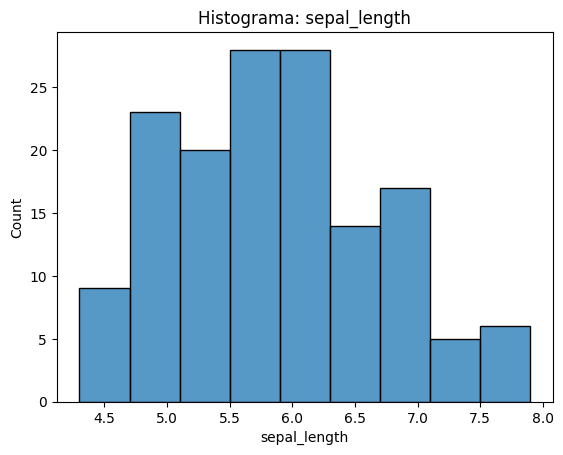

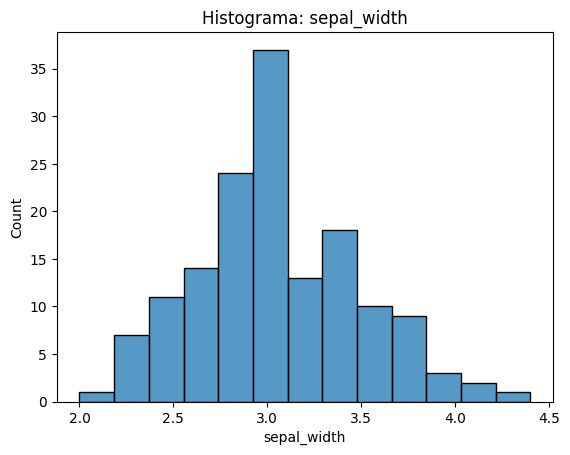

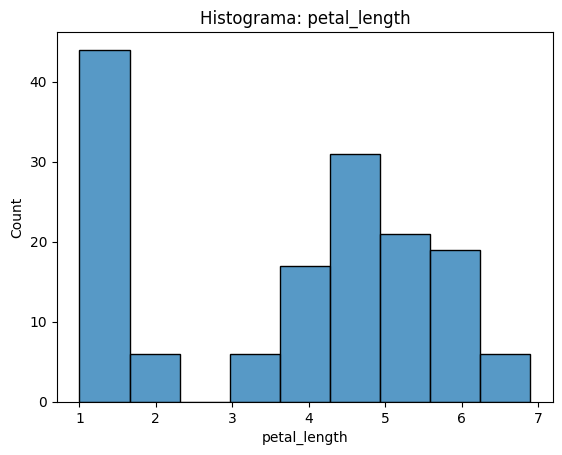

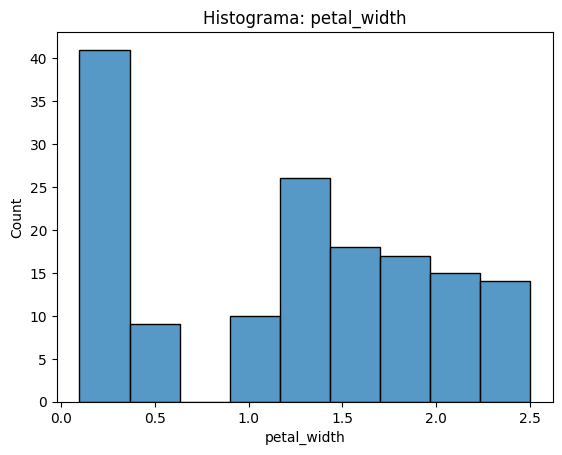

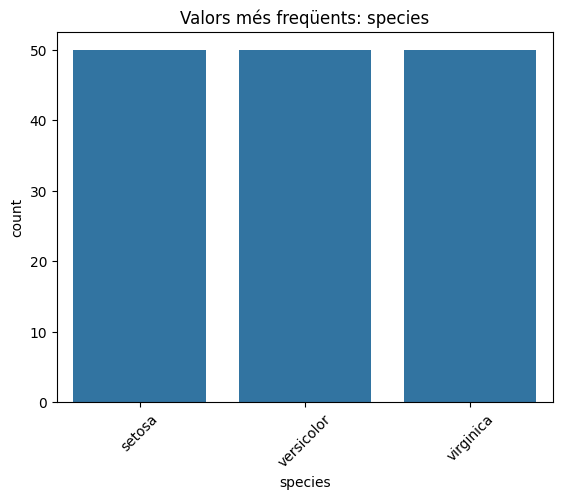

In [33]:
iris = sns.load_dataset("iris")
plot_auto_seaborn(iris)

2. 
    * Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.
        Font: Mejores Rutas
    * Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.
    * **No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.**
    * Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara
    * Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.
    * **(EXTRA)** Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat.

In [37]:
matriz = pd.read_excel("matriu_distancies.xlsx", index_col=0)
#matriz

to_drop = ["Las Palmas de Gran Canaria", "Palma"]
matriz = matriz.drop(index=to_drop, columns= to_drop)
#print(matriz.index)

def ciutat_mes_propera(matriz_dist, ciutat_actual, no_visitades):
    distancies = matriz_dist.loc[ciutat_actual, list(no_visitades)]
    ciutat = distancies.idxmin()
    distancia = distancies.min()
    return ciutat, distancia

def ruta_mes_propera(matriz_dist, origen):
    ciutats =list(matriz_dist.index)
    if origen not in ciutats:
        raise ValueError("La ciutat d'origen no ès a la matriu")
    
    ruta = [origen]
    no_visitades= set (ciutats)
    no_visitades.remove(origen)
    total = 0.0
    ciutat_actual = origen

    while no_visitades:
        ciutat_propera, d= ciutat_mes_propera(matriz_dist, ciutat_actual, no_visitades)
        ruta.append(ciutat_propera)
        total += d
        no_visitades.remove(ciutat_propera)
        ciutat_actual = ciutat_propera
    
    return ruta, total

lista_ciutats = list(matriz.index)
#print(lista_ciutats)

origen = lista_ciutats[1]
ruta, distancia_total = ruta_mes_propera(matriz, origen)
print(f"""Ciutat origen: {origen}, 
Ruta proposada: {ruta}, 
Distancia Total: {distancia_total}""")

Ciutat origen: Valencia, 
Ruta proposada: ['Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Zaragoza', 'Hospitalet de Llobregat', 'Barcelona', 'Vigo'], 
Distancia Total: 3200.0


In [38]:
def millor_origen(matriz_dist):
    millor_ciutat = None
    millor_ruta = None
    millor_distancia = None

    for ciutat in matriz_dist.index:
        ruta, total = ruta_mes_propera(matriz_dist, ciutat)
        if millor_distancia is None or total < millor_distancia:
            millor_distancia = total
            millor_ciutat = ciutat
            millor_ruta = ruta

    return millor_ciutat, millor_ruta, millor_distancia

ciutat_inicial, ruta_min, dist_min = millor_origen(matriz)

print(f"""Millor ciutat origen: {ciutat_inicial}, 
Ruta proposada: {ruta_min}, 
Distancia Total: {dist_min}""")


Millor ciutat origen: Barcelona, 
Ruta proposada: ['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Sevilla', 'Córdoba', 'Málaga', 'Murcia', 'Alicante', 'Valencia'], 
Distancia Total: 2646.0
